In [38]:
import matplotlib.pyplot as plt
import numpy as np

In [39]:
x = np.linspace(0.001, 1.0, 1000)
y = np.log(x)

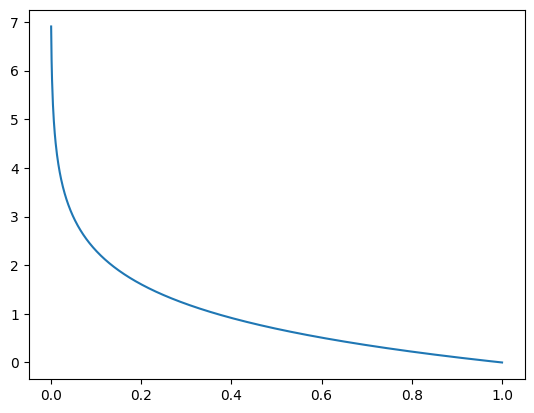

In [40]:
plt.plot(x, -y)
plt.show()

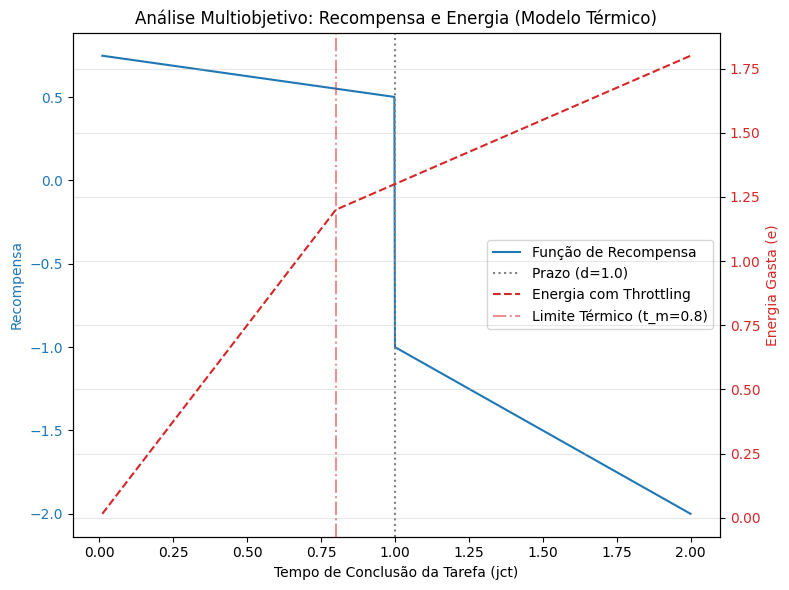

In [50]:
import numpy as np
import matplotlib.pyplot as plt

def reward(jct, d, e_max):
    if jct < d:
        return 1.0 - 0.25 * (jct/d + e_max)
    else:
        return -1.0 - min(1.0, (jct-d)/d)

# Cálculo de consumo energético modelado por partes (Thermal Throttling)
def energia_gasta_dinamica(jct, t_m=0.8, p_pico=1.5, p_seg=0.5):
    if jct <= t_m:
        # Operação em alta performance
        return p_pico * jct
    else:
        # Operação sob thermal throttling após t_m
        energia_pico = p_pico * t_m
        energia_residual = p_seg * (jct - t_m)
        return energia_pico + energia_residual

d = 1.0
e_max = 1.0
t_m = 0.8 # Limite de tempo antes do throttling
data_jct = np.linspace(0.01, 2.0, 1000)

r_values = [reward(i, d, e_max) for i in data_jct]
e_values = [energia_gasta_dinamica(i, t_m) for i in data_jct]

fig, ax1 = plt.subplots(figsize=(8, 6))

# Plotagem da Recompensa
color1 = 'tab:blue'
ax1.set_xlabel('Tempo de Conclusão da Tarefa (jct)')
ax1.set_ylabel('Recompensa', color=color1)
ax1.plot(data_jct, r_values, color=color1, label='Função de Recompensa')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.axvline(x=d, color='gray', linestyle=':', label=f'Prazo (d={d})')

ax2 = ax1.twinx()  

# Plotagem da Energia com inflexão térmica
color2 = 'tab:red'
ax2.set_ylabel('Energia Gasta (e)', color=color2)
ax2.plot(data_jct, e_values, color=color2, linestyle='--', label='Energia com Throttling')
ax2.tick_params(axis='y', labelcolor=color2)
# Marcação do ponto de inflexão térmica
ax2.axvline(x=t_m, color='tab:red', linestyle='-.', alpha=0.5, label=f'Limite Térmico (t_m={t_m})')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')

plt.title('Análise Multiobjetivo: Recompensa e Energia (Modelo Térmico)')
fig.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

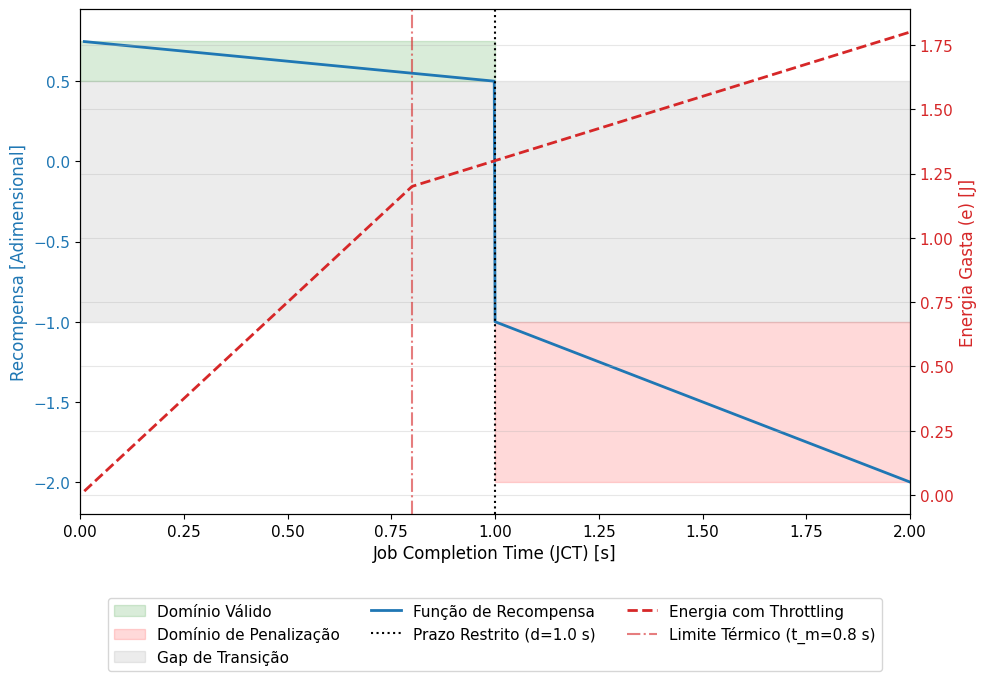

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Configuração global de tipografia
plt.rcParams.update({
    'font.size': 11,
    'legend.fontsize': 11,
    'axes.labelsize': 12
})

def reward(jct, d, e_max):
    if jct < d:
        return 1.0 - 0.25 * (jct/d + e_max)
    else:
        return -1.0 - min(1.0, (jct-d)/d)

def energia_gasta_dinamica(jct, t_m=0.8, p_pico=1.5, p_seg=0.5):
    if jct <= t_m:
        return p_pico * jct
    else:
        energia_pico = p_pico * t_m
        energia_residual = p_seg * (jct - t_m)
        return energia_pico + energia_residual

d = 1.0
e_max = 1.0
t_m = 0.8
x_max = 2.0 
data_jct = np.linspace(0.01, x_max, 1000)

r_values = [reward(i, d, e_max) for i in data_jct]
e_values = [energia_gasta_dinamica(i, t_m) for i in data_jct]

# Limites Analíticos da Recompensa
r_max_valido = 1.0 - 0.25 * (0.0/d + e_max)   # 0.75
r_min_valido = 1.0 - 0.25 * (d/d + e_max)     # 0.5
r_max_penalidade = -1.0                       # Início da violação
r_min_penalidade = -2.0                       # Saturação máxima

# Alteração da proporção: Largura 12 polegadas, Altura 5 polegadas
fig, ax1 = plt.subplots(figsize=(10, 7))

# Plotagem dos Retângulos Delimitadores (Patches)
rect_valido = Rectangle((0.0, r_min_valido), width=d, height=(r_max_valido - r_min_valido),
                        color='green', alpha=0.15, label='Domínio Válido')
ax1.add_patch(rect_valido)

rect_penalidade = Rectangle((d, r_min_penalidade), width=(x_max - d), height=(r_max_penalidade - r_min_penalidade),
                            color='red', alpha=0.15, label='Domínio de Penalização')
ax1.add_patch(rect_penalidade)

rect_gap = Rectangle((0.0, r_max_penalidade), width=x_max, height=(r_min_valido - r_max_penalidade),
                     color='gray', alpha=0.15, label='Gap de Transição')
ax1.add_patch(rect_gap)

# Plotagem da Recompensa
color1 = 'tab:blue'
ax1.set_xlabel('Job Completion Time (JCT) [s]')
ax1.set_ylabel('Recompensa [Adimensional]', color=color1)
ax1.plot(data_jct, r_values, color=color1, linewidth=2, label='Função de Recompensa')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.axvline(x=d, color='black', linestyle=':', linewidth=1.5, label=f'Prazo Restrito (d={d} s)')

# Eixo Secundário para Energia
ax2 = ax1.twinx()  
color2 = 'tab:red'
ax2.set_ylabel('Energia Gasta (e) [J]', color=color2)
ax2.plot(data_jct, e_values, color=color2, linestyle='--', linewidth=2, label='Energia com Throttling')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.axvline(x=t_m, color='tab:red', linestyle='-.', alpha=0.6, label=f'Limite Térmico (t_m={t_m} s)')

# Ajuste dos limites do gráfico
ax1.set_xlim(0.0, x_max)
ax1.set_ylim(r_min_penalidade - 0.2, r_max_valido + 0.2)

# Unificação das legendas
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

# Posicionamento da legenda estruturado para a parte inferior com 3 colunas
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, 
           loc='upper center', 
           bbox_to_anchor=(0.5, -0.15), 
           ncol=3)

# plt.title('Engenharia de Recompensa')
fig.tight_layout()
plt.grid(True, alpha=0.3)
plt.savefig("reward.pdf", format='pdf', bbox_inches='tight')
plt.show()